<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/3D_Mesh_and_FEA_Basic_Picnic_Bench_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

,Node,1D Simulation,3D Simulation
0,1,1.5000e-04,1.53100e-04
1,2,1.3438e-04,1.35960e-04
2,3,1.0312e-04,1.04060e-04
3,4,4.6875e-05,5.21700e-05
4,5,1.5625e-05,1.81200e-05
5,6,0.0000e+00,0.00000e+00


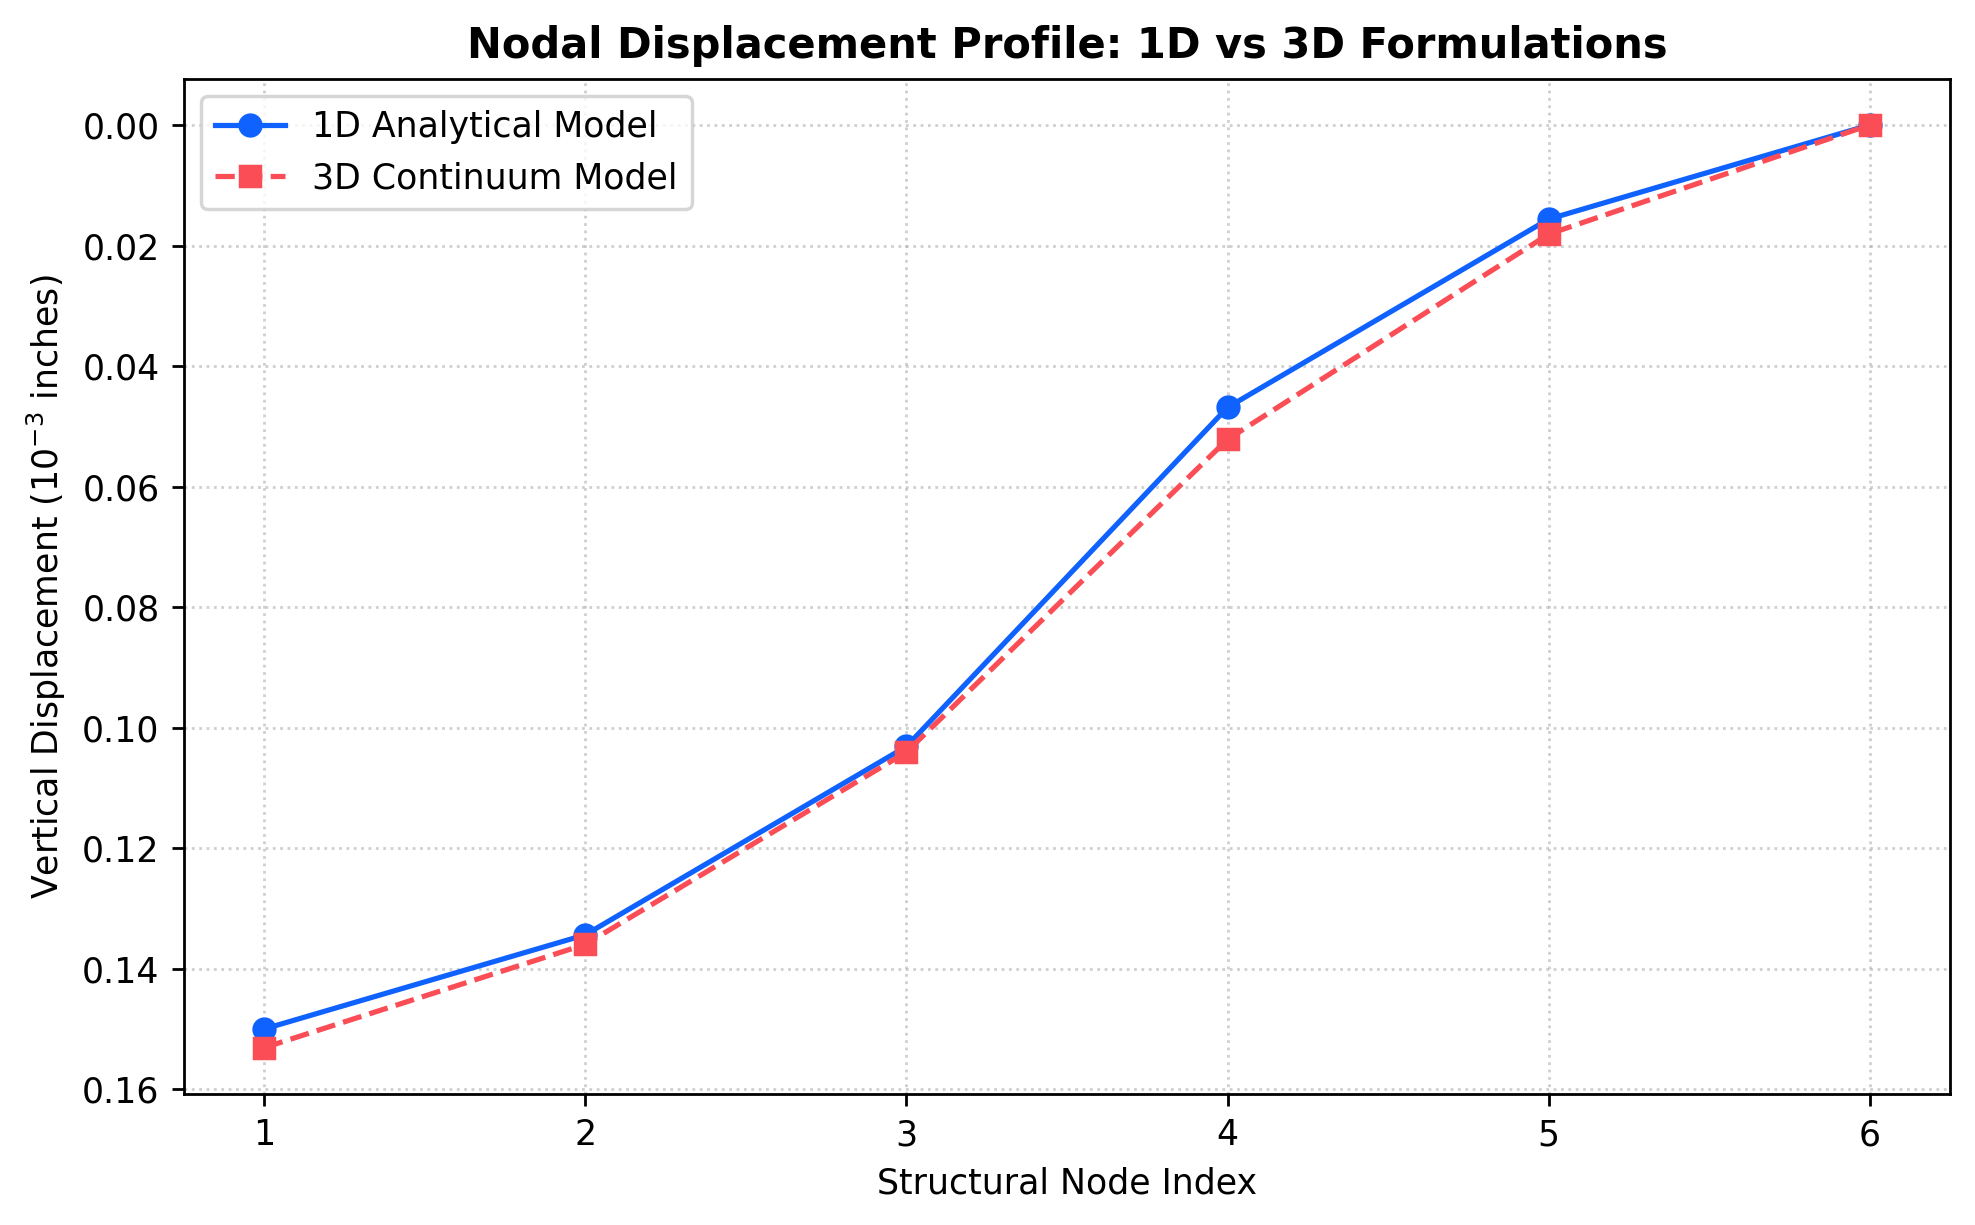

In [9]:
"""
Finite Element Analysis module for structural evaluation and three dimensional mesh generation.

This script calculates the exact one dimensional nodal displacements for a
discrete variable cross section structure and generates the corresponding
three dimensional mesh utilizing Gmsh, rendering the final comparison natively as an HTML table.
"""

# Install system level dependencies required for Gmsh in Google Colab
!apt-get update > /dev/null 2>&1
!apt-get install -y libglu1-mesa libxcursor1 libxft2 libxinerama1 > /dev/null 2>&1

# Execute the following package installation in a Google Colab cell
%pip install numpy pandas matplotlib gmsh

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import gmsh
from IPython.display import display

# ==============================================================================
# CONTROL KNOBS
# ==============================================================================
YOUNGS_MODULUS = 4.0e6  # psi (Concrete material property)
APPLIED_FORCE = 1000.0  # lb (Downward axial force)
DEPTH = 4.0             # inches (Uniform structural depth)

# Geometry definitions (heights and widths in inches, from top to bottom)
GEOMETRY_SEGMENTS = [
    {"length": 4.0, "width_top": 16.0, "width_bottom": 16.0},  # Element 1
    {"length": 6.5, "width_top": 16.0, "width_bottom": 10.0},  # Element 2
    {"length": 9.0, "width_top": 10.0, "width_bottom": 10.0},  # Element 3
    {"length": 6.5, "width_top": 10.0, "width_bottom": 16.0},  # Element 4
    {"length": 4.0, "width_top": 16.0, "width_bottom": 16.0},  # Element 5
]

# Validation data sourced from continuous three dimensional Ansys Simulation
VALIDATION_3D_DISPLACEMENTS = [0.1531e-3, 0.13596e-3, 0.10406e-3, 0.05217e-3, 0.01812e-3, 0.0]

# ==============================================================================
# PLOT CONFIGURATION
# ==============================================================================
mpl.rcParams['font.sans-serif'] = ['IBM Plex Sans', 'DejaVu Sans', 'Arial', 'sans-serif']
mpl.rcParams['font.weight'] = 'normal'
mpl.rcParams['axes.titleweight'] = 'semibold'
mpl.rcParams['figure.dpi'] = 250


def calculate_1d_displacements() -> np.ndarray:
    """
    Constructs the global stiffness matrix and solves for nodal displacements.

    Returns:
        np.ndarray: The computed displacements at each of the 6 nodes.
    """
    num_elements = len(GEOMETRY_SEGMENTS)
    num_nodes = num_elements + 1
    stiffness_values = np.zeros(num_elements)

    # Calculate individual spring constants based on average cross sectional area
    for i, segment in enumerate(GEOMETRY_SEGMENTS):
        average_width = (segment["width_top"] + segment["width_bottom"]) / 2.0
        area = average_width * DEPTH
        stiffness_values[i] = (area * YOUNGS_MODULUS) / segment["length"]

    # Assemble the symmetric global stiffness matrix
    K_global = np.zeros((num_nodes, num_nodes))
    for i in range(num_elements):
        k_i = stiffness_values[i]
        K_global[i, i] += k_i
        K_global[i, i+1] -= k_i
        K_global[i+1, i] -= k_i
        K_global[i+1, i+1] += k_i

    # Define the external force vector
    F = np.zeros(num_nodes)
    F[0] = APPLIED_FORCE

    # Apply boundary conditions (Node 6 is fixed to the ground)
    K_reduced = K_global[0:5, 0:5]
    F_reduced = F[0:5]

    # Solve the linear system Ku = F
    u_reduced = np.linalg.solve(K_reduced, F_reduced)

    # Reconstruct the full displacement vector including the boundary condition
    u_full = np.append(u_reduced, [0.0])
    return u_full


def generate_3d_mesh() -> None:
    """
    Initializes Gmsh API to programmatically generate the three dimensional
    continuum geometry and apply meshing steps.
    """
    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 0)
    gmsh.model.add("picnic_bench_support")

    mesh_size = 1.0

    # Calculate vertical coordinate accumulation from the bottom upwards
    y_coords = [0.0]
    for seg in reversed(GEOMETRY_SEGMENTS):
        y_coords.append(y_coords[-1] + seg["length"])

    widths = [
        GEOMETRY_SEGMENTS[4]["width_bottom"],
        GEOMETRY_SEGMENTS[4]["width_top"],
        GEOMETRY_SEGMENTS[3]["width_top"],
        GEOMETRY_SEGMENTS[2]["width_top"],
        GEOMETRY_SEGMENTS[1]["width_top"],
        GEOMETRY_SEGMENTS[0]["width_top"]
    ]

    points = []
    # Construct right side profile
    for i in range(len(y_coords)):
        x_val = widths[i] / 2.0
        points.append(gmsh.model.geo.addPoint(x_val, y_coords[i], 0.0, mesh_size))

    # Construct left side profile in reverse order to close the polygon
    for i in range(len(y_coords)-1, -1, -1):
        x_val = -widths[i] / 2.0
        points.append(gmsh.model.geo.addPoint(x_val, y_coords[i], 0.0, mesh_size))

    lines = []
    for i in range(len(points)-1):
        lines.append(gmsh.model.geo.addLine(points[i], points[i+1]))
    lines.append(gmsh.model.geo.addLine(points[-1], points[0]))

    curve_loop = gmsh.model.geo.addCurveLoop(lines)
    surface = gmsh.model.geo.addPlaneSurface([curve_loop])

    # Extrude the 2D surface into a 3D volume
    gmsh.model.geo.extrude([(2, surface)], 0.0, 0.0, DEPTH)

    gmsh.model.geo.synchronize()
    gmsh.model.mesh.generate(3)

    gmsh.finalize()


def run_simulation() -> None:
    """
    Executes the analytical solver, triggers the meshing routine, and visually
    reports the outcome comparison.
    """
    u_1d = calculate_1d_displacements()
    generate_3d_mesh()

    nodes = np.arange(1, 7)

    # Construct a formatted comparison table
    df_results = pd.DataFrame({
        "Node": nodes,
        "1D Simulation": [f"{val:.4e}" for val in u_1d],
        "3D Simulation": [f"{val:.5e}" for val in VALIDATION_3D_DISPLACEMENTS]
    })

    # Apply rendering styles for the Google Colab graphical interface
    styled_comparison = (df_results.style
                     .set_caption("Simulation Comparison Table")
                     .set_table_styles([{
                         'selector': 'caption',
                         'props': [
                             ('font-size', '16px'),
                             ('font-weight', 'bold'),
                             ('color', '#333333'),
                             ('padding-bottom', '10px')
                         ]
                     }, {
                         'selector': 'th',
                         'props': [
                             ('font-family', 'IBM Plex Sans, sans-serif'),
                             ('text-align', 'center')
                         ]
                     }, {
                         'selector': 'td',
                         'props': [
                             ('font-family', 'IBM Plex Sans, sans-serif'),
                             ('text-align', 'center'),
                             ('padding', '8px')
                         ]
                     }]))

    # Render the styled object directly into the cell output
    display(styled_comparison)

    # Generate a visual comparison plot rendered directly in the notebook environment
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(nodes, u_1d * 1e3, marker='o', linestyle='solid', color='#0f62fe', label='1D Analytical Model')
    ax.plot(nodes, np.array(VALIDATION_3D_DISPLACEMENTS) * 1e3, marker='s', linestyle='dashed', color='#fa4d56', label='3D Continuum Model')

    ax.set_title('Nodal Displacement Profile: 1D vs 3D Formulations')
    ax.set_xlabel('Structural Node Index')
    ax.set_ylabel('Vertical Displacement ($10^{-3}$ inches)')
    ax.invert_yaxis()  # Invert axis to visually represent downward displacement
    ax.grid(True, linestyle='dotted', alpha=0.6)
    ax.legend(frameon=True)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    run_simulation()

In [6]:
"""
Three Dimensional Finite Element Deformation Visualization Module.

This script calculates the theoretical structural displacements, generates a
three dimensional mesh utilizing Gmsh, extracts the topological surface boundaries,
interpolates the deformation field across the spatial volume, and renders an
interactive surface heatmap using Plotly scaled to metric units.
"""

# Install system-level dependencies required for Gmsh in Google Colab
!apt-get update > /dev/null 2>&1
!apt-get install -y libglu1-mesa libxcursor1 libxft2 libxinerama1 > /dev/null 2>&1

# Execute the following package installation in a Google Colab cell
%pip install numpy pandas matplotlib gmsh plotly

import numpy as np
import gmsh
import plotly.graph_objects as go

# ==============================================================================
# CONTROL KNOBS
# ==============================================================================
YOUNGS_MODULUS = 4.0e6  # psi (Concrete material property)
APPLIED_FORCE = 1000.0  # lb (Downward axial force on top face)
DEPTH = 4.0             # inches (Uniform structural depth)
MESH_SIZE_FACTOR = 1.2  # Controls mesh density (lower is denser)
INCHES_TO_METERS = 0.0254  # Metric unit conversion scalar

# Geometry definitions (heights and widths in inches, from top to bottom)
GEOMETRY_SEGMENTS = [
    {"length": 4.0, "width_top": 16.0, "width_bottom": 16.0},  # Element 1
    {"length": 6.5, "width_top": 16.0, "width_bottom": 10.0},  # Element 2
    {"length": 9.0, "width_top": 10.0, "width_bottom": 10.0},  # Element 3
    {"length": 6.5, "width_top": 10.0, "width_bottom": 16.0},  # Element 4
    {"length": 4.0, "width_top": 16.0, "width_bottom": 16.0},  # Element 5
]

def calculate_nodal_displacements() -> tuple[np.ndarray, np.ndarray]:
    """
    Computes the exact nodal displacements and their corresponding vertical elevations.

    Returns:
        tuple[np.ndarray, np.ndarray]: A tuple containing the structural elevations
        (y-coordinates) and their corresponding absolute displacement values.
    """
    num_elements = len(GEOMETRY_SEGMENTS)
    num_nodes = num_elements + 1
    stiffness_values = np.zeros(num_elements)

    for i, segment in enumerate(GEOMETRY_SEGMENTS):
        average_width = (segment["width_top"] + segment["width_bottom"]) / 2.0
        area = average_width * DEPTH
        stiffness_values[i] = (area * YOUNGS_MODULUS) / segment["length"]

    K_global = np.zeros((num_nodes, num_nodes))
    for i in range(num_elements):
        k_i = stiffness_values[i]
        K_global[i, i] += k_i
        K_global[i, i+1] -= k_i
        K_global[i+1, i] -= k_i
        K_global[i+1, i+1] += k_i

    F = np.zeros(num_nodes)
    F[0] = APPLIED_FORCE

    K_reduced = K_global[0:5, 0:5]
    F_reduced = F[0:5]

    u_reduced = np.linalg.solve(K_reduced, F_reduced)
    u_full = np.append(u_reduced, [0.0])

    # Calculate corresponding y-coordinates from the bottom up
    y_coords = [0.0]
    for seg in reversed(GEOMETRY_SEGMENTS):
        y_coords.append(y_coords[-1] + seg["length"])

    # Reverse to match top-down node ordering (Node 1 at top, Node 6 at bottom)
    y_coords_reversed = np.array(y_coords[::-1])

    return y_coords_reversed, u_full

def generate_and_render_heatmap() -> None:
    """
    Generates the three dimensional geometry, extracts the meshed surface topology,
    maps the displacement field, and renders the interactive graphical object.
    """
    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 0)

    # Force triangular elements for Plotly compatibility
    gmsh.option.setNumber("Mesh.RecombineAll", 0)
    gmsh.option.setNumber("Mesh.Algorithm", 5)

    gmsh.model.add("picnic_bench_support")

    y_levels = [0.0]
    for seg in reversed(GEOMETRY_SEGMENTS):
        y_levels.append(y_levels[-1] + seg["length"])

    widths = [
        GEOMETRY_SEGMENTS[4]["width_bottom"],
        GEOMETRY_SEGMENTS[4]["width_top"],
        GEOMETRY_SEGMENTS[3]["width_top"],
        GEOMETRY_SEGMENTS[2]["width_top"],
        GEOMETRY_SEGMENTS[1]["width_top"],
        GEOMETRY_SEGMENTS[0]["width_top"]
    ]

    points = []
    # Construct right-side profile
    for i in range(len(y_levels)):
        points.append(gmsh.model.geo.addPoint(widths[i] / 2.0, y_levels[i], 0.0, MESH_SIZE_FACTOR))

    # Construct left-side profile
    for i in range(len(y_levels)-1, -1, -1):
        points.append(gmsh.model.geo.addPoint(-widths[i] / 2.0, y_levels[i], 0.0, MESH_SIZE_FACTOR))

    lines = []
    for i in range(len(points)-1):
        lines.append(gmsh.model.geo.addLine(points[i], points[i+1]))
    lines.append(gmsh.model.geo.addLine(points[-1], points[0]))

    curve_loop = gmsh.model.geo.addCurveLoop(lines)
    surface = gmsh.model.geo.addPlaneSurface([curve_loop])

    # Extrude the volume and generate the 3D mesh
    gmsh.model.geo.extrude([(2, surface)], 0.0, 0.0, DEPTH)
    gmsh.model.geo.synchronize()
    gmsh.model.mesh.generate(3)

    # Extract nodal coordinates
    nodeTags, nodeCoords, _ = gmsh.model.mesh.getNodes()
    nodes_xyz = np.array(nodeCoords).reshape(-1, 3)

    # Map Gmsh global node tags to local array indices
    node_map = {tag: idx for idx, tag in enumerate(nodeTags)}

    # Extract two dimensional surface elements (triangles)
    elemTypes, elemTags, elemNodeTags = gmsh.model.mesh.getElements(dim=2)

    triangles = []
    for i, eType in enumerate(elemTypes):
        if eType == 2:  # Gmsh identifier for 3-node triangles
            tags = np.array(elemNodeTags[i]).reshape(-1, 3)
            for tri in tags:
                triangles.append([node_map[tri[0]], node_map[tri[1]], node_map[tri[2]]])

    triangles = np.array(triangles)
    gmsh.finalize()

    # Retrieve discrete solutions and interpolate across the continuous volume
    y_discrete, u_discrete = calculate_nodal_displacements()

    # The physical structure is anchored at y=0, therefore sorting ensures proper interpolation
    sort_idx = np.argsort(y_discrete)
    y_discrete_sorted = y_discrete[sort_idx]
    u_discrete_sorted = u_discrete[sort_idx]

    # Project the scalar deformation values onto every geometrical vertex and convert to meters
    vertex_displacements = np.interp(nodes_xyz[:, 1], y_discrete_sorted, u_discrete_sorted) * INCHES_TO_METERS

    # Construct the interactive Plotly surface mesh
    fig = go.Figure(data=[go.Mesh3d(
        x=nodes_xyz[:, 0],
        y=nodes_xyz[:, 1],
        z=nodes_xyz[:, 2],
        i=triangles[:, 0],
        j=triangles[:, 1],
        k=triangles[:, 2],
        intensity=vertex_displacements,
        colorscale='Jet',
        intensitymode='vertex',
        colorbar=dict(
            title='Total Deformation (m)',
            x=1.0,
            thickness=20,
            xpad=25
        ),
        showscale=True,
        flatshading=True
    )])

    fig.update_layout(
        title='Three Dimensional Total Deformation Heatmap',
        scene=dict(
            xaxis_title='X Axis (in)',
            yaxis_title='Y Axis (in)',
            zaxis_title='Z Axis (in)',
            aspectmode='data'
        ),
        width=900,
        height=700,
        margin=dict(l=0, r=150, b=0, t=50) # Significantly increased right margin
    )

    fig.show()

if __name__ == "__main__":
    generate_and_render_heatmap()

In [8]:
"""
Global Stiffness Matrix Rendering Module.

This script calculates the individual axial spring constants for a discrete
variable cross-section structure and constructs the complete unconstrained
global stiffness matrix, outputting a rich HTML table for native notebook rendering.
"""

# Execute the following package installation in a Google Colab cell prior to running
# %pip install numpy pandas

import numpy as np
import pandas as pd
from IPython.display import display

# ==============================================================================
# CONTROL KNOBS
# ==============================================================================
YOUNGS_MODULUS = 4.0e6  # psi (Concrete material property)
DEPTH = 4.0             # inches (Uniform structural depth)

# Geometry definitions (heights and widths in inches, from top to bottom)
GEOMETRY_SEGMENTS = [
    {"length": 4.0, "width_top": 16.0, "width_bottom": 16.0},  # Element 1
    {"length": 6.5, "width_top": 16.0, "width_bottom": 10.0},  # Element 2
    {"length": 9.0, "width_top": 10.0, "width_bottom": 10.0},  # Element 3
    {"length": 6.5, "width_top": 10.0, "width_bottom": 16.0},  # Element 4
    {"length": 4.0, "width_top": 16.0, "width_bottom": 16.0},  # Element 5
]

def render_global_stiffness_matrix() -> None:
    """
    Calculates individual element stiffness values, constructs the symmetric
    global stiffness matrix, and triggers the rich notebook display.
    """
    num_elements = len(GEOMETRY_SEGMENTS)
    num_nodes = num_elements + 1
    stiffness_values = np.zeros(num_elements)

    # Calculate individual spring constants based on average cross-sectional area
    for i, segment in enumerate(GEOMETRY_SEGMENTS):
        average_width = (segment["width_top"] + segment["width_bottom"]) / 2.0
        area = average_width * DEPTH
        stiffness_values[i] = (area * YOUNGS_MODULUS) / segment["length"]

    # Assemble the symmetric global stiffness matrix
    K_global = np.zeros((num_nodes, num_nodes))
    for i in range(num_elements):
        k_i = stiffness_values[i]
        K_global[i, i] += k_i
        K_global[i, i+1] -= k_i
        K_global[i+1, i] -= k_i
        K_global[i+1, i+1] += k_i

    # Convert the raw NumPy array into a structured Pandas DataFrame
    node_labels = [f"Node {i}" for i in range(1, num_nodes + 1)]
    df_stiffness = pd.DataFrame(K_global, index=node_labels, columns=node_labels)

    # Apply rendering styles for the Google Colab graphical interface
    styled_matrix = (df_stiffness.style
                     .format("{:.3e}")
                     .set_caption("Global Stiffness Matrix (lb/in)")
                     .set_table_styles([{
                         'selector': 'caption',
                         'props': [
                             ('font-size', '16px'),
                             ('font-weight', 'bold'),
                             ('color', '#333333'),
                             ('padding-bottom', '10px')
                         ]
                     }, {
                         'selector': 'th',
                         'props': [
                             ('font-family', 'IBM Plex Sans, sans-serif'),
                             ('text-align', 'center')
                         ]
                     }, {
                         'selector': 'td',
                         'props': [
                             ('font-family', 'IBM Plex Sans, sans-serif'),
                             ('text-align', 'right'),
                             ('padding', '8px')
                         ]
                     }]))

    # Render the styled object directly into the cell output
    display(styled_matrix)

if __name__ == "__main__":
    render_global_stiffness_matrix()

,Node 1,Node 2,Node 3,Node 4,Node 5,Node 6
Node 1,6.400e+07,-6.400e+07,0.000e+00,0.000e+00,0.000e+00,0.000e+00
Node 2,-6.400e+07,9.600e+07,-3.200e+07,0.000e+00,0.000e+00,0.000e+00
Node 3,0.000e+00,-3.200e+07,4.978e+07,-1.778e+07,0.000e+00,0.000e+00
Node 4,0.000e+00,0.000e+00,-1.778e+07,4.978e+07,-3.200e+07,0.000e+00
Node 5,0.000e+00,0.000e+00,0.000e+00,-3.200e+07,9.600e+07,-6.400e+07
Node 6,0.000e+00,0.000e+00,0.000e+00,0.000e+00,-6.400e+07,6.400e+07
